# 🚀 2강. 요즘 음악의 에너지와 템포 비교 (AI Pair) 🎚

> 📌 **이 노트북의 목표**
> - "요즘 노래는 더 빠르고 더 에너지가 높다"는 흔한 말을, BPM·RMS·spectral centroid 같은 숫자로 직접 확인합니다.
> - 여러 곡을 **같은 기준의 숫자 벡터**로 바꿔서 나란히 비교하는 감각을 만듭니다.

> **오늘의 위치**: **1강**에서 노래 한 곡의 파형·RMS 에너지를 눈으로 봤다면, 오늘은 그 감각을 **여러 곡을 한 번에 비교하는 표**로 확장합니다. 1강이 "한 곡을 자세히"였다면, 2강은 "여러 곡을 같은 잣대로"입니다.

> 🧭 **이 강이 다루지 않는 것**
> - 이 피처들을 이용해 곡을 자동으로 묶는 것(클러스터링) → **3강**에서 다룹니다.
> - 소리를 이미지로 바꿔서 보는 멜스펙트로그램 → **4강**에서 다룹니다.
> - 지금은 "숫자로 곡을 요약하는 법"에만 집중합니다 — 묶고 분류하는 건 다음 강들의 몫입니다.

## 🔑 오늘의 핵심 스캐폴딩 — 처음 만나는 함수/패턴

| 핵심 함수/패턴 | 역할 한 줄 | 처음 등장 |
|---|---|---|
| `librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=30.0)` | 오디오 파일을 지정한 샘플레이트로 불러와 앞 30초만 numpy 배열로 반환 | [Step 1] |
| `librosa.onset.onset_strength(y, sr)` | 소리가 "커지기 시작하는 지점"(온셋)의 강도를 프레임마다 계산 — 템포 추정의 재료 | [Step 1] |
| `librosa.feature.tempo(onset_envelope, sr)` | 온셋 강도의 자기상관(autocorrelation)으로 BPM(분당 박자 수)을 추정 | [Step 1] |
| `librosa.feature.rms(y)` | 짧은 프레임마다 진폭의 제곱평균제곱근(RMS)을 계산해 평균 에너지를 추정 | [Step 1] |
| `librosa.feature.spectral_centroid(y, sr)` | 주파수 성분의 무게중심 — 소리가 얼마나 "밝은지" | [Step 1] |
| `librosa.feature.zero_crossing_rate(y)` | 파형이 0선을 지나는 빈도 — 거칠음·타격감 | [Step 1] |
| `librosa.feature.spectral_rolloff(y, sr)` | 에너지 대부분이 모이는 주파수 상단 경계 | [Step 1] |

> 오늘 새로 만나는 함수는 이 7개가 전부입니다. 각 함수가 실제로 어떤 숫자를 내는지는 바로 다음 [Step 1]에서 확인합니다.

> **📐 오늘의 계약 5줄** — 이 다섯 줄이 맞으면 절반은 성공입니다
> 1. **입력**: 오디오 파일 1개(`.wav`/`.mp3` 등), `SAMPLE_RATE=22050`, 앞 30초만 분석
> 2. **출력**: 곡 1개당 `{bpm, rms_energy, brightness_centroid, zero_crossing_rate, rolloff}` 딕셔너리 1개
> 3. **여러 곡 결과**: `pandas.DataFrame` — 행 = 곡, 열 = 피처
> 4. **비교 단위**: 모든 곡이 같은 `SAMPLE_RATE`·같은 `duration`으로 추출되어야 숫자 비교가 공정함
> 5. **검증 한 줄**: `set(extract_features(path).keys()) == {"file","bpm","rms_energy","brightness_centroid","zero_crossing_rate","rolloff"}`

In [1]:
# [패키지 확인] 처음 실행하는 환경이면 필요한 패키지를 조용히 설치합니다.
import importlib.util
import subprocess
import sys

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "librosa": "librosa",
    "soundfile": "soundfile",
    "sklearn": "scikit-learn",
}

for module_name, package_name in required.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"[설치] {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
    else:
        print(f"[OK] {package_name}")

print("패키지 준비 완료")

[OK] numpy
[OK] pandas
[OK] matplotlib
[OK] librosa
[OK] soundfile
[OK] scikit-learn
패키지 준비 완료


> 💡 **준비 코드 안내**: 바로 아래 두 셀(`환경 설정`, `데이터 찾기`)은 오디오 파일을 자동으로 찾아주는 준비 코드입니다. 내부 로직(경로 탐색 우선순위)을 지금 다 이해할 필요는 없고, 실행 후 출력되는 **발견한 오디오 파일 목록**만 확인하고 넘어가도 됩니다.

In [2]:
# [환경 설정] 오디오 분석에 필요한 도구를 준비합니다.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import Audio, display

try:
    import librosa
    import librosa.display
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "librosa가 필요합니다. Colab/로컬에서 `pip install librosa soundfile` 후 다시 실행하세요."
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)

# 한글 그래프가 깨질 때를 줄이기 위한 후보 폰트 설정입니다.
# (주의) plt.rcParams["font.family"] 대입 자체는 폰트가 실제로 설치돼 있지
# 않아도 예외를 던지지 않습니다 — 그래서 "존재하면 쓰고 없으면 다음 후보로"
# 식의 try/except 루프는 항상 첫 번째 후보에서만 break하고 끝나버립니다.
# 대신 matplotlib이 실제로 인식한 설치 폰트 목록(fontManager.ttflist)에서
# 후보를 찾아 그중 진짜 존재하는 첫 폰트를 선택합니다.
plt.rcParams["axes.unicode_minus"] = False
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_font_candidates = ["AppleGothic", "NanumGothic", "Malgun Gothic", "DejaVu Sans"]
_selected_font = next((f for f in _font_candidates if f in _installed_fonts), _font_candidates[-1])
plt.rcParams["font.family"] = _selected_font
print(f"[폰트] 선택된 한글 폰트: {_selected_font}")

SAMPLE_RATE = 22_050
AUDIO_EXTS = {".wav", ".mp3", ".flac", ".m4a", ".ogg"}

# 현재 폴더와 상위 폴더에서 Data/를 자동으로 찾습니다 — 노트북을 강의_AI_Pair/에서 열든
# 그 위 AI_Music/에서 열든 동작합니다. /content 경로는 Colab 표준 위치입니다.
def find_music_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd(),
        Path("/content/Music"),
        Path("/content"),
    ]
    for root in candidates:
        if (root / "Data").exists():
            return root
    return Path.cwd()


MUSIC_ROOT = find_music_root()
DATA_DIR = MUSIC_ROOT / "Data"
GENERATED_DIR = DATA_DIR / "generated_loops"
LATEST_DIR = DATA_DIR / "latest_music_local"
ATTENTION_FILE = DATA_DIR / "NewJeans-Attention.wav"

print(f"[경로] MUSIC_ROOT = {MUSIC_ROOT}")
print(f"[경로] DATA_DIR   = {DATA_DIR}")
print(f"[경로] LATEST_DIR = {LATEST_DIR}")

[폰트] 선택된 한글 폰트: AppleGothic
[경로] MUSIC_ROOT = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/AI_Music
[경로] DATA_DIR   = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/AI_Music/Data
[경로] LATEST_DIR = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/AI_Music/Data/latest_music_local


In [3]:
# [데이터 찾기] 기본 샘플과 로컬 최신곡 샘플을 한 번에 모읍니다.
def collect_audio_files() -> list[Path]:
    files: list[Path] = []

    # 1순위: 사용자가 넣어둔 최신곡 로컬 샘플
    latest_dirs = [LATEST_DIR]
    for latest_dir in latest_dirs:
        if latest_dir.exists():
            files.extend(sorted(p for p in latest_dir.iterdir() if p.suffix.lower() in AUDIO_EXTS))

    # 2순위: 공용 Attention 샘플
    attention_candidates = [ATTENTION_FILE]
    for attention_path in attention_candidates:
        if attention_path.exists():
            files.append(attention_path)

    # 3순위: 수업용 합성 루프
    generated_dirs = [GENERATED_DIR]
    for generated_dir in generated_dirs:
        if generated_dir.exists():
            files.extend(sorted(p for p in generated_dir.glob("*.wav") if p.is_file()))

    unique: list[Path] = []
    seen = set()
    for path in files:
        key = path.resolve()
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


audio_files = collect_audio_files()
if not audio_files:
    checked = [str(LATEST_DIR), str(GENERATED_DIR)]
    raise FileNotFoundError(
        "분석할 오디오를 찾지 못했습니다. 확인한 경로:\n- " + "\n- ".join(checked)
    )

print(f"[발견] 분석 가능한 오디오 {len(audio_files)}개")
for i, path in enumerate(audio_files[:12], 1):
    print(f"  {i:02d}. {path.name}")
if len(audio_files) > 12:
    print(f"  ... 외 {len(audio_files) - 12}개")

[발견] 분석 가능한 오디오 13개
  01.  Your Shampoo Scent In The Flowers.mp3
  02. Grown Ups.mp3
  03. NewJeans-Attention.wav
  04. 사랑하게 될 거야.mp3
  05. 예뻤어 You Were Beautiful.mp3
  06. ambient_70bpm_soft_15s.wav
  07. ballad_80bpm_warm_15s.wav
  08. citypop_105bpm_glossy_15s.wav
  09. dance_120bpm_bright_15s.wav
  10. funk_110bpm_bouncy_15s.wav
  11. hiphop_95bpm_dark_15s.wav
  12. hyperpop_145bpm_sharp_15s.wav
  ... 외 1개


---
## 1. 코드 전에 보는 핵심 지표

2강에서 쓰는 값들은 **모델이 아니라 오디오 특징 지표(feature)**입니다. 모델은 보통 이 숫자들을 입력으로 받아 분류, 추천, 클러스터링을 합니다. 오늘은 모델을 학습하기 전에, 음악을 설명하는 숫자 언어를 먼저 익힙니다.

| 지표 | 한 줄 정의 | 사람이 듣는 느낌과의 연결 | 주의할 점 |
|---|---|---|---|
| BPM / Tempo | 1분 동안의 박자 수 | 빠른 곡, 느린 곡, 댄스감 | 발라드도 드럼 패턴 때문에 높게 추정될 수 있음 |
| RMS Energy | 파형 진폭의 평균 에너지 | 평균적으로 크고 강한 소리 | 볼륨 정규화, 믹싱, 압축 영향을 크게 받음 |
| Spectral Centroid | 주파수 무게중심 | 밝음, 선명함, 날카로움 | 고음 악기나 노이즈가 있으면 높아짐 |
| Zero Crossing Rate | 파형이 0선을 지나는 빈도 | 거칠음, 타격감, 노이즈성 | 드럼, 하이햇, 치찰음에 민감함 |
| Spectral Rolloff | 에너지 대부분이 모이는 주파수 경계 | 고음역이 얼마나 넓게 퍼졌는지 | centroid와 비슷하지만 더 "상단 경계"에 가까움 |

### 🎯 일상 비유로 느껴보기 — centroid와 ZCR

- **Spectral Centroid = 소리의 무게중심 높이**: 저음(베이스·킥드럼)이 많으면 무게중심이 아래로 가라앉고, 심벌즈·하이햇처럼 고음 타악기가 많이 섞이면 무게중심이 위로 올라갑니다. "이 곡은 위쪽이 화려하다"는 느낌이 곧 centroid가 높다는 뜻입니다.
- **Zero Crossing Rate = 파형이 얼마나 자주 흔들리나**: 파형이 0선을 자주 넘나들수록(고주파·노이즈성 성분이 많을수록) 값이 커집니다. 's', 'ㅊ' 같은 치찰음, 하이햇·심벌즈의 "쉬익" 소리, 혹은 단순 배경 잡음이 섞이면 ZCR이 함께 올라갑니다.

### 이 지표들이 하는 일

예를 들어 어떤 곡이 `BPM=125`, `RMS 높음`, `centroid 높음`이라면 우리는 이렇게 해석할 수 있습니다.

> 빠른 템포이고, 평균 에너지가 크며, 고음역 성분이 많아서 밝고 선명하게 들릴 가능성이 높다.

반대로 `BPM=80`, `RMS 낮음`, `centroid 낮음`이면 차분하고 따뜻한 곡일 가능성이 큽니다. 물론 이것은 정답이 아니라 **해석의 출발점**입니다.

### 오늘의 관점

- 음악 감상: "이 곡은 청량하다"
- 오디오 지표: "centroid와 rolloff가 높고, RMS가 중간 이상이다"
- 머신러닝 입력: `[bpm, rms, centroid, zcr, rolloff]` 같은 숫자 벡터

이제 아래 코드에서 각 곡을 같은 기준으로 숫자 벡터로 바꿔봅니다.

> 💡 **Rolloff를 일상 비유로**: 저음부터 고음까지 에너지를 아래에서부터 차곡차곡 쌓아 올렸을 때, 전체의 85%가 쌓이는 높이(주파수)가 rolloff입니다 — "이 소리의 천장이 어디까지 닿아 있는가"를 재는 것과 같습니다. centroid가 '무게중심'이라면 rolloff는 '거의 다 담기는 상한선'입니다.

> ▶ **실행 전 예측** — 바로 위 셀에서 출력된 파일 목록을 다시 보고, 코드를 실행하기 전에 먼저 적어보세요.
> - 파일명만 보고 판단할 때, 어떤 곡이 BPM(템포)이 가장 높을 것 같나요?
> - RMS 에너지(평균 소리 크기)가 가장 큰 곡은 어떤 곡일 것 같나요? 파일명의 `bpm` 숫자(있다면)와 실제 추정 BPM이 비슷할까요?
> - 아래 [Step 1]을 실행해 실제 값을 확인한 뒤, 이 예측과 비교해보세요.

In [4]:
# [Step 1] 위 지표들을 곡별 숫자 피처로 추출합니다.
def extract_features(path: Path, duration: float = 30.0) -> dict:
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=duration)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    tempo = float(librosa.feature.tempo(onset_envelope=onset_env, sr=sr)[0])
    rms = float(np.mean(librosa.feature.rms(y=y)[0]))
    centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0]))
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(y)[0]))
    rolloff = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)[0]))
    return {
        "file": path.name,
        "bpm": round(tempo, 1),
        "rms_energy": round(rms, 4),
        "brightness_centroid": round(centroid, 1),
        "zero_crossing_rate": round(zcr, 4),
        "rolloff": round(rolloff, 1),
    }

features_df = pd.DataFrame([extract_features(path) for path in audio_files])
features_df

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,file,bpm,rms_energy,brightness_centroid,zero_crossing_rate,rolloff
0,Your Shampoo Scent In The Flowers.mp3,99.4,0.2356,1959.6,0.0595,4636.8
1,Grown Ups.mp3,117.5,0.0836,1316.9,0.0444,2729.3
2,NewJeans-Attention.wav,103.4,0.2346,2427.4,0.1060,5056.3
3,사랑하게 될 거야.mp3,92.3,0.1212,1662.6,0.0543,3227.9
4,예뻤어 You Were Beautiful.mp3,172.3,0.1073,1598.2,0.0664,3313.9
5,ambient_70bpm_soft_15s.wav,95.7,0.1933,323.6,0.0218,551.4
6,ballad_80bpm_warm_15s.wav,161.5,0.1728,714.8,0.0298,1494.8
7,citypop_105bpm_glossy_15s.wav,103.4,0.1279,1065.2,0.0404,2220.1
8,dance_120bpm_bright_15s.wav,117.5,0.1427,1158.6,0.0350,2530.6
9,funk_110bpm_bouncy_15s.wav,112.3,0.1284,1158.5,0.0379,2418.9


### 🔍 확인해보기 — RMS를 librosa 없이 직접 계산해도 같을까?

`librosa.feature.rms()`는 내부적으로 짧은 구간(프레임)마다 `sqrt(mean(y**2))`를 계산한 뒤 평균을 냅니다. 정말 그런지, 파형 전체를 한 번에 `sqrt(mean(y**2))`로 계산한 값과 얼마나 비슷한지 직접 확인해봅니다.

In [5]:
# [확인해보기] librosa RMS(프레임 평균) vs 전체 파형 한 번에 계산한 RMS
sample_path = audio_files[0]
y_check, sr_check = librosa.load(sample_path, sr=SAMPLE_RATE, mono=True, duration=30.0)

rms_librosa = float(np.mean(librosa.feature.rms(y=y_check)[0]))
rms_whole = float(np.sqrt(np.mean(y_check ** 2)))

print(f"파일: {sample_path.name}")
print(f"librosa RMS(프레임 평균) : {rms_librosa:.4f}")
print(f"전체 파형 RMS(한 번에)   : {rms_whole:.4f}")
print(f"차이                     : {abs(rms_librosa - rms_whole):.4f}")
print()
print("두 값이 완전히 같지는 않습니다 — 프레임 평균은 조용한 구간과 시끄러운 구간을")
print("먼저 나눠 각각 계산한 뒤 평균 내므로, 곡 전체를 한 번에 계산하는 것과 미세하게 달라질 수 있습니다.")

파일:  Your Shampoo Scent In The Flowers.mp3
librosa RMS(프레임 평균) : 0.2356
전체 파형 RMS(한 번에)   : 0.2509
차이                     : 0.0153

두 값이 완전히 같지는 않습니다 — 프레임 평균은 조용한 구간과 시끄러운 구간을
먼저 나눠 각각 계산한 뒤 평균 내므로, 곡 전체를 한 번에 계산하는 것과 미세하게 달라질 수 있습니다.


In [6]:
# [미리 확인] Step 4는 아직 실행하지 않았습니다 — 여기서는 Step 4가 나중에 쓸
# 판정 기준값만 먼저 계산해둡니다(지어낸 숫자가 아니라 실제 계산값입니다).
rms_median = features_df["rms_energy"].median()
print(f"[Step 4에서 쓸 판정 기준 — 미리보기] RMS 에너지 중앙값(이 {len(features_df)}곡 기준): {rms_median:.4f}")

[Step 4에서 쓸 판정 기준 — 미리보기] RMS 에너지 중앙값(이 13곡 기준): 0.1361


### 📊 결과 해석 — [Step 1] 피처 추출 전체 요약

이 해석은 Step 2~4의 그래프 각각이 아니라, **Step 1에서 추출한 원본 숫자(bpm·rms_energy·brightness_centroid)** 자체에 대한 것입니다. 그래프별 해석은 각 Step 코드 바로 아래 [📊 결과 해석]을 참고하세요.

- BPM은 빠르기를, RMS는 평균 에너지를, spectral centroid는 밝고 날카로운 느낌을 대략적으로 보여줍니다.
- 최신곡 로컬 샘플을 추가하면 "요즘 음악"과 합성 루프를 같은 기준으로 비교할 수 있습니다.
- 숫자가 감상을 대신하지는 않지만, 감상을 설명하는 근거가 됩니다.

**실제 실행 결과(이 13개 샘플 기준)**:
- `ballad_80bpm_warm_15s.wav`는 파일명 그대로면 BPM 80이어야 하는데, 실제 추정값은 **161.5**로 나왔습니다 — 정확히 2배에 가깝습니다. 바로 아래 [불확실성 참고]에서 설명하는 "옥타브 오차"가 실제로 이 샘플에서 관측된 것입니다.
- RMS 에너지가 가장 높은 파일은 `Your Shampoo Scent In The Flowers.mp3`(0.2356)와 `NewJeans-Attention.wav`(0.2346)로 거의 비슷했고, `Grown Ups.mp3`(0.0836)가 가장 낮았습니다.
- brightness(centroid)가 가장 높은 파일은 `NewJeans-Attention.wav`(2427.4)였고, 가장 낮은 파일은 `ambient_70bpm_soft_15s.wav`(323.6)였습니다 — 이름 그대로 "ambient(잔잔한)"인 곡이 가장 어둡고 따뜻한 음색으로 나온 셈입니다.
- (아직 실행 전인 [Step 4]를 미리보면) `ambient_70bpm_soft_15s.wav`는 자동 코멘트가 "에너지가 큰 편"으로 나오는데, 이 역시 이름과 반대로 보입니다. 판정 기준이 절대 RMS 값이 아니라 **이 13곡의 RMS 중앙값(바로 위 코드 셀의 실제 출력값)**이기 때문에, ambient의 RMS(0.1933)가 낮게 들려도 이 데이터셋 안에서는 중앙값보다 높게 잡힙니다.
- 또한 합성 루프(ambient·ballad·citypop 등)는 발매된 실제곡과 달리 **볼륨 정규화(라우드니스 노멀라이제이션)가 되어 있지 않아**, RMS를 실제곡과 1:1로 비교하는 것 자체가 공정하지 않습니다 — 이 데이터셋의 RMS·에너지 비교는 "제작 방식이 다른 두 그룹을 섞어 놓은" 상태라는 한계를 감안해야 합니다.

**그래서 "요즘 노래가 더 빠르고 에너지 높은가?"(cell 0의 질문)에 대한 답은**: 실제곡 5곡(mp3·`NewJeans-Attention.wav`)의 평균은 BPM 117.0·RMS 0.1565였고, 합성 루프 8곡의 평균은 BPM 108.9·RMS 0.1476으로, 이 샘플 안에서는 실제곡 쪽이 근소하게 더 빠르고 에너지도 근소하게 높았습니다. 다만 실제곡 5곡 중 1곡(`예뻤어 You Were Beautiful.mp3`, 172.3bpm)이 평균을 크게 끌어올린 값이고, 실제곡·합성 루프 모두 표본이 5~8개뿐이라 — **13개 샘플로는 "요즘 음악이 더 빠르고 에너지 높다"고 통계적으로 판정할 수 없습니다.** 이 노트북의 목적은 결론을 확정하는 것이 아니라, 그 질문을 숫자로 확인하는 절차를 익히는 것입니다.

> 🎲 **불확실성 참고**: `librosa.feature.tempo()`의 BPM 추정은 온셋(onset) 강도의 자기상관(autocorrelation)에 기반합니다 — 이 방식은 **옥타브 오차(octave error)**에 취약해서, 실제 BPM이 140이어도 정확히 절반(70)이나 두 배(280)로 잘못 추정하는 경우가 흔합니다. 특히 드럼 패턴이 약하거나 리듬이 불규칙한 곡에서 이런 현상이 두드러집니다. RMS·centroid 값도 믹싱·마스터링(볼륨 정규화, 압축)의 영향을 크게 받으므로, "이 장르가 원래 에너지가 높다"보다는 "이 특정 음원 파일이 그렇게 마스터링되었다" 정도로 해석하는 것이 안전합니다.

> 💡 **온셋·자기상관을 일상 비유로**: '온셋'은 소리가 갑자기 커지는 순간(예: 드럼 킥이 터지는 찰나)을 감지한 것이고, '자기상관'은 그 순간들 사이의 간격이 규칙적으로 반복되는 주기를 찾는 계산입니다 — 박수를 일정한 간격으로 칠 때, 그 간격을 컴퓨터가 거꾸로 알아맞히는 것과 같습니다. 문제는 **박수를 2배 빠르게 쳐도(간격을 반으로 줄여도) 여전히 '규칙적인 박자'로는 보인다는 점**입니다 — 그래서 컴퓨터가 원래 박자의 절반/두 배를 정답으로 착각하기 쉽습니다(옥타브 오차). 사람은 '이건 너무 빠르다/느리다'는 감각으로 걸러내지만, 컴퓨터는 그 감각이 없어 순수하게 반복 주기만 봅니다.

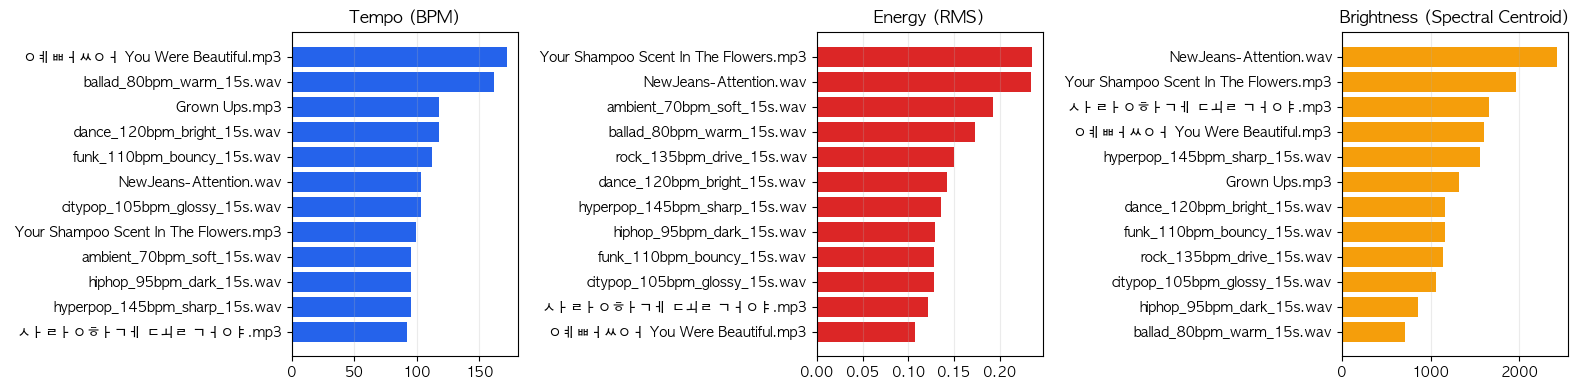

In [7]:
# [Step 2] 빠름, 밝음, 에너지를 한눈에 비교합니다.
plot_df = features_df.sort_values("bpm", ascending=False).head(12)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].barh(plot_df["file"], plot_df["bpm"], color="#2563eb")
axes[0].set_title("Tempo (BPM)")
axes[0].invert_yaxis()

energy_df = features_df.sort_values("rms_energy", ascending=False).head(12)
axes[1].barh(energy_df["file"], energy_df["rms_energy"], color="#dc2626")
axes[1].set_title("Energy (RMS)")
axes[1].invert_yaxis()

bright_df = features_df.sort_values("brightness_centroid", ascending=False).head(12)
axes[2].barh(bright_df["file"], bright_df["brightness_centroid"], color="#f59e0b")
axes[2].set_title("Brightness (Spectral Centroid)")
axes[2].invert_yaxis()

for ax in axes:
    ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 📊 결과 해석 — Step 2

- **숫자의 의미**: 왼쪽부터 BPM(빠르기) · RMS 에너지(평균 크기) · Spectral Centroid(밝기) 기준 상위 12곡을 각각 막대로 나열했습니다.
- **무엇을 보나**: 세 그래프의 1등 곡이 서로 다릅니다 — "빠른 곡 = 시끄러운 곡 = 밝은 곡"이 아니라는 뜻이고, 세 지표가 항상 같이 움직이지는 않는다는 뜻입니다.
- **결론**: 한 곡을 지표 하나로 요약하면 정보를 잃습니다. 곡의 성격을 판단하려면 최소 3개 지표를 나란히 봐야 합니다.

> 📐 **아래 그래프 읽는 법(코드 미리보기)**: 이 산점도는 한 점(곡)을 4가지 정보로 동시에 표현합니다 — 가로 위치(BPM) · 세로 위치(밝기) · **점 크기**(에너지가 클수록 점이 커짐) · **점 색**(오른쪽 컬러바, 밝을수록 zero-crossing rate가 높음 = 거칠거나 타격감 있는 소리). `size = 80 + rms_energy/최댓값 * 420`은 "에너지가 0에 가까우면 점 크기 80, 최댓값이면 500"이 되도록 비율을 크기로 환산하는 공식입니다.

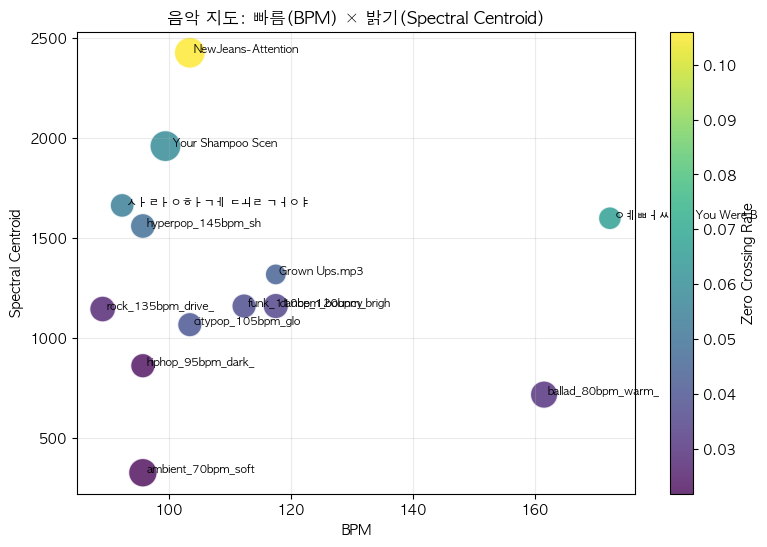

In [8]:
# [Step 3] 산점도로 곡의 위치를 비교합니다.
fig, ax = plt.subplots(figsize=(9, 6))
size = 80 + features_df["rms_energy"] / max(features_df["rms_energy"].max(), 1e-6) * 420
scatter = ax.scatter(
    features_df["bpm"],
    features_df["brightness_centroid"],
    s=size,
    c=features_df["zero_crossing_rate"],
    cmap="viridis",
    alpha=0.78,
    edgecolor="white",
    linewidth=1,
)
for _, row in features_df.iterrows():
    ax.text(row["bpm"] + 0.6, row["brightness_centroid"], row["file"][:18], fontsize=8)
ax.set_title("음악 지도: 빠름(BPM) × 밝기(Spectral Centroid)")
ax.set_xlabel("BPM")
ax.set_ylabel("Spectral Centroid")
ax.grid(alpha=0.25)
plt.colorbar(scatter, ax=ax, label="Zero Crossing Rate")
plt.show()

### 📊 결과 해석 — Step 3

- **숫자의 의미**: x축 BPM, y축 spectral centroid, 점 크기는 RMS 에너지, 점 색은 zero crossing rate — 산점도 한 장에 4개 지표를 동시에 담았습니다.
- **무엇을 보나**: 오른쪽 위에 몰린 점은 "빠르고 밝은" 곡, 왼쪽 아래는 "느리고 어두운" 곡입니다. 점이 크면서 색이 밝은(ZCR 높은) 곡은 에너지도 크고 거친 질감까지 겹친 곡입니다.
- **결론**: 곡 하나하나가 2차원 좌표 위 점이 되면서 "가까운 위치의 곡 = 비슷한 분위기"라는 감각이 생깁니다. 이 감각이 3강 클러스터링의 출발점입니다.

In [9]:
# [Step 4] 숫자를 사람이 읽는 말로 바꿔봅니다.
def describe_track(row: pd.Series) -> str:
    tempo_word = "빠른" if row["bpm"] >= features_df["bpm"].median() else "느긋한"
    energy_word = "에너지가 큰" if row["rms_energy"] >= features_df["rms_energy"].median() else "차분한"
    bright_word = "밝은 질감" if row["brightness_centroid"] >= features_df["brightness_centroid"].median() else "따뜻한 질감"
    return f"{tempo_word} 템포, {energy_word} 편, {bright_word}"

features_df["auto_comment"] = features_df.apply(describe_track, axis=1)
features_df[["file", "bpm", "rms_energy", "brightness_centroid", "auto_comment"]]

,file,bpm,rms_energy,brightness_centroid,auto_comment
0,Your Shampoo Scent In The Flowers.mp3,99.4,0.2356,1959.6,"느긋한 템포, 에너지가 큰 편, 밝은 질감"
1,Grown Ups.mp3,117.5,0.0836,1316.9,"빠른 템포, 차분한 편, 밝은 질감"
2,NewJeans-Attention.wav,103.4,0.2346,2427.4,"빠른 템포, 에너지가 큰 편, 밝은 질감"
3,사랑하게 될 거야.mp3,92.3,0.1212,1662.6,"느긋한 템포, 차분한 편, 밝은 질감"
4,예뻤어 You Were Beautiful.mp3,172.3,0.1073,1598.2,"빠른 템포, 차분한 편, 밝은 질감"
5,ambient_70bpm_soft_15s.wav,95.7,0.1933,323.6,"느긋한 템포, 에너지가 큰 편, 따뜻한 질감"
6,ballad_80bpm_warm_15s.wav,161.5,0.1728,714.8,"빠른 템포, 에너지가 큰 편, 따뜻한 질감"
7,citypop_105bpm_glossy_15s.wav,103.4,0.1279,1065.2,"빠른 템포, 차분한 편, 따뜻한 질감"
8,dance_120bpm_bright_15s.wav,117.5,0.1427,1158.6,"빠른 템포, 에너지가 큰 편, 밝은 질감"
9,funk_110bpm_bouncy_15s.wav,112.3,0.1284,1158.5,"빠른 템포, 차분한 편, 따뜻한 질감"


### 📊 결과 해석 — Step 4

- **숫자의 의미**: 각 곡의 bpm·rms_energy·brightness_centroid를 **13곡 전체의 중앙값**과 비교해 "빠른/느긋한", "에너지가 큰/차분한", "밝은/따뜻한" 세 단어로 자동 번역했습니다.
- **무엇을 보나**: `ambient_70bpm_soft_15s.wav`가 "에너지가 큰 편", `ballad_80bpm_warm_15s.wav`가 "빠른 템포"로 나오는 등 이름과 반대되는 결과가 보입니다 — 판정 기준이 절대값이 아니라 **이 13곡 안에서의 상대적 중앙값**이기 때문입니다.
- **결론**: 합성 루프는 실제 발매곡과 달리 볼륨 정규화(라우드니스 노멀라이제이션)가 되어 있지 않아, RMS를 실제곡과 직접 비교하는 것은 공정하지 않습니다. `auto_comment`를 읽을 때는 반드시 "무엇과 비교한 상대값인지"를 함께 확인해야 합니다.

> 🤖 **AI Agent에서 이렇게 씁니다**: 방금 뽑은 `bpm`·`rms_energy`·`brightness_centroid` 같은 숫자는, 이 강의 시리즈 뒷부분에서 만들 **텍스트→음악 생성 에이전트**의 조건(condition)으로 그대로 재사용됩니다. 사용자가 "신나고 빠른 템포의 K-pop 느낌으로"라고 말하면, 에이전트는 이 말을 `bpm≈128, energy=high, brightness=high` 같은 숫자 조건으로 번역한 뒤 음악 생성 모델에 넘깁니다 — 오늘 여러분이 눈으로 확인한 "숫자 ↔ 감상" 번역이, 나중에는 "자연어 ↔ 숫자 조건" 번역으로 한 단계 더 확장되는 셈입니다.

---
## 🤝 AI Pair 섹션 — 오디오 피처 비교

> **목표**: AI를 답 베끼는 도구가 아니라 *내 코드·판단을 검증해주는 동료*로 쓴다. (읽기용 — 실습 시간엔 핵심만 따라가도 됩니다)

| 단계 | 내가 하는 것 | AI가 하는 것 |
|---|---|---|
| 1️⃣ Solo | 먼저 직접 작성/판단 | (아직 X) |
| 2️⃣ Review | 내 코드·판단을 제출 | 리뷰 + 근거 설명 |
| 3️⃣ Debug | AI가 준 "조용히 틀린" 코드의 결함 찾기 | 의도적 버그 제공 |
| 4️⃣ Prompt Card | 실험 설계 프롬프트 익히기 | — |

### 1️⃣ Solo — 먼저 스스로 풀어보세요
💡 *AI에게 물으면 30초 만에 답이 나오지만, 지금 막히는 지점이 이해의 핵심입니다.*

### 🧩 Solo 전에 하나만 더 — Spectral Bandwidth (Solo 레벨 1 준비)

Solo 레벨 1은 오늘 배운 5개 피처에 **spectral bandwidth**라는 새 피처를 하나 추가합니다. 지금까지 다룬 7개 함수 목록(맨 위 [🔑 오늘의 핵심 스캐폴딩])에는 없던 함수라서, 여기서 먼저 무엇을 계산하는지 확인하고 넘어갑니다.

**선수 지식과 연결**: 위에서 배운 spectral centroid는 "주파수의 무게중심"이었습니다. bandwidth는 그 무게중심 **주변으로 주파수 성분이 얼마나 넓게 퍼져 있는지**를 재는 값입니다 — 평균(무게중심)과 표준편차(퍼짐 정도)의 관계와 같은 원리입니다. bandwidth가 크면 여러 음역대의 소리가 함께 섞여 있는(예: 여러 악기가 동시에 울리는) 곡이고, bandwidth가 작으면 좁은 음역대에 몰려 있는(예: 단일 악기 톤에 가까운) 곡입니다.

`librosa.feature.spectral_bandwidth(y=y, sr=sr)`도 다른 spectral 계열 함수처럼 프레임마다 값을 내므로, 지금까지와 똑같이 평균을 내서 곡 하나의 대표값으로 씁니다.


In [10]:
# [Solo 전 준비] spectral_bandwidth가 실제로 어떤 값을 내는지 먼저 확인해봅니다.
# (바로 위 [확인해보기] 셀에서 만든 sample_path·y_check·sr_check를 그대로 재사용합니다.)
bandwidth_check = librosa.feature.spectral_bandwidth(y=y_check, sr=sr_check)[0]

print(f"파일: {sample_path.name}")
print(f"spectral_bandwidth 프레임 개수: {bandwidth_check.shape[0]}")
print(f"spectral_bandwidth 평균값     : {np.mean(bandwidth_check):.1f}")
print(
    "(참고) 같은 파일의 brightness_centroid: "
    f"{features_df.loc[features_df['file'] == sample_path.name, 'brightness_centroid'].values[0]:.1f}"
)


파일:  Your Shampoo Scent In The Flowers.mp3
spectral_bandwidth 프레임 개수: 1292
spectral_bandwidth 평균값     : 2508.9
(참고) 같은 파일의 brightness_centroid: 1959.6


### ✏️ [Solo 레벨 1] 직접 작성해 보세요 — spectral bandwidth 피처 추가

힌트: extract_features 함수를 복사해서, librosa.feature.spectral_bandwidth(y=y, sr=sr)를 추가하세요.
기존 5개 피처(bpm, rms_energy, brightness_centroid, zero_crossing_rate, rolloff)에
"bandwidth" 키를 하나 더 추가한 새 DataFrame을 만들어 출력하세요.
(바로 위 [Solo 전 준비] 셀에서 spectral_bandwidth를 어떻게 계산하는지 이미 확인했습니다 —
그 계산 한 줄을 extract_features 복사본 안에 그대로 옮겨 넣으면 됩니다.)

In [11]:
def extract_features_with_bandwidth(path: Path, duration: float = 30.0) -> dict:
    # TODO: extract_features의 내용을 그대로 복사한 뒤,
    #       bandwidth = float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)[0])) 한 줄만 추가하고
    #       반환 딕셔너리에 "bandwidth": round(bandwidth, 1)을 추가하세요.
    ...

### ✏️ [Solo 레벨 2] 직접 작성해 보세요 — duration을 30초 → 10초로 줄이면 순위가 바뀔까?

힌트: extract_features(path, duration=10.0)으로 다시 계산한 뒤,
bpm 기준 정렬 순위가 원래(30초) 결과와 같은지 다른지 비교하세요.
순위가 바뀐 곡이 있다면 왜 그런지 짧게 적어보세요.
([Step 2]에서 쓴 features_df.sort_values("bpm", ascending=False)["file"].tolist() 패턴을
10초 버전 결과에도 똑같이 적용하면, 두 파일명 리스트를 나란히 비교할 수 있습니다.)

In [12]:
# TODO: 여기에 작성하세요

### 🧩 Solo 전에 하나만 더 — 0~1 정규화 (Solo 레벨 3 준비)

Solo 레벨 3은 bpm·rms_energy·brightness_centroid 세 값을 더해 "에너지 점수"를 만듭니다. 그런데 이 세 값은 **단위와 크기가 전혀 다릅니다** — bpm은 대략 70~180, rms_energy는 0~0.3, brightness_centroid는 300~2500 사이입니다. 이대로 더하면 숫자가 큰 brightness_centroid가 점수를 거의 혼자 결정해버립니다(국어 점수 0~100점과 키 cm를 그냥 더하면 키가 점수를 압도하는 것과 같은 문제입니다).

그래서 세 값을 **같은 0~1 범위로 맞춘 뒤** 평균 내야 공정합니다. 이렇게 범위를 맞추는 것을 정규화(normalization)라고 하고, 가장 단순한 방법이 **min-max 정규화**입니다.

```
x_norm = (x - x.min()) / (x.max() - x.min())
```

이 식은 데이터의 최솟값을 0, 최댓값을 1로 만들고 나머지는 그 사이 비율로 배치합니다. 아래에서 `rolloff` 열 하나로 미리 계산해봅니다 — Solo 레벨 3이 실제로 쓸 bpm·rms_energy·brightness_centroid는 여러분이 직접 계산해야 하므로, 여기서는 다른 열로 동작 방식만 연습합니다.


In [13]:
# [Solo 전 준비] min-max 정규화가 실제로 어떻게 동작하는지, 다른 열(rolloff)로 먼저 연습합니다.
# (Solo 레벨 3이 쓸 bpm·rms_energy·brightness_centroid는 여러분이 직접 계산해보세요.)
rolloff_raw = features_df["rolloff"]
rolloff_norm = (rolloff_raw - rolloff_raw.min()) / (rolloff_raw.max() - rolloff_raw.min())

print("정규화 전 rolloff 범위:", f"{rolloff_raw.min():.1f} ~ {rolloff_raw.max():.1f}")
print("정규화 후 rolloff 범위:", f"{rolloff_norm.min():.2f} ~ {rolloff_norm.max():.2f}")
pd.DataFrame({"file": features_df["file"], "rolloff": rolloff_raw, "rolloff_norm": rolloff_norm}).head(3)


정규화 전 rolloff 범위: 551.4 ~ 5056.3
정규화 후 rolloff 범위: 0.00 ~ 1.00


,file,rolloff,rolloff_norm
0,Your Shampoo Scent In The Flowers.mp3,4636.8,0.906879
1,Grown Ups.mp3,2729.3,0.483451
2,NewJeans-Attention.wav,5056.3,1.000000


### ✏️ [Solo 레벨 3] 직접 작성해 보세요 — "에너지 점수" 자동 랭킹 함수

힌트:
1) def energetic_score(df): ... 함수를 만드세요.
2) bpm, rms_energy, brightness_centroid 각각을 0~1로 정규화한 뒤 평균 내 "energetic_score" 열을 추가하세요.
(정규화 예: (x - x.min()) / (x.max() - x.min()) — 바로 위 [Solo 전 준비] 셀에서 rolloff로 연습한 것과 같은 식입니다.)
3) energetic_score가 가장 높은 상위 3곡을 막대그래프로 그려 보세요.

In [14]:
def energetic_score(df):
    # TODO: 1) bpm, rms_energy, brightness_centroid 세 열을 각각 min-max 정규화
    # TODO: 2) 정규화된 세 값의 평균을 "energetic_score" 새 열로 df에 추가
    # TODO: 3) df를 반환(return)
    pass


### 2️⃣ Review
아래 프롬프트를 복사해 ChatGPT/Claude에 붙여넣으세요.
```text
librosa로 오디오에서 BPM(tempo), RMS energy, spectral centroid, zero crossing rate, spectral rolloff를 추출하는 함수를 만들었습니다.
tempo는 librosa.onset.onset_strength로 온셋 강도를 구한 뒤 librosa.feature.tempo로 추정합니다.
1) BPM 추정이 왜 "옥타브 오차"(실제 템포의 절반/두 배로 잘못 추정)에 취약한지,
2) RMS energy와 spectral centroid가 왜 믹싱/마스터링에 크게 영향받는지,
3) 이 5개 피처만으로 "장르"까지 구분하기엔 왜 부족한지(3강 클러스터링·5강 장르분류로 이어지는 이유) 설명해줘.
```

In [15]:
# ── 2️⃣ Review (코드형) — 로컬/클라우드 LLM에게 내 코드·판단을 리뷰받기 ──
# [사전조건] 로컬: LM Studio/Ollama 서버 실행  |  클라우드: OPENROUTER/OPENAI 키 설정
# [실패 시] 아래 셀이 Connection error를 내면 로컬 LLM 서버가 없는 것이 정상입니다 —
#          이 코드형 Review는 선택 사항이며, 바로 앞 셀의 복붙용 프롬프트를
#          ChatGPT/Claude 등에 붙여넣는 것으로 똑같이 리뷰받을 수 있습니다.
# openai 패키지가 없으면 아래 주석을 풀어 한 번만 실행하세요 (이미 있으면 건너뛰기)
# !pip install openai
import os
try:
    from openai import OpenAI
except ImportError:
    OpenAI = None

if OpenAI is None:
    print("[안내] openai 패키지가 없어 이 Review 셀을 건너뜁니다 — `!pip install openai` 후 다시 실행하세요(선택 사항입니다).")
else:
    PROVIDER = "lmstudio"   # "lmstudio" | "ollama" | "openrouter" | "openai"  ← 한 줄만 바꾸면 전환
    PROVIDERS = {
        "lmstudio":   {"base_url": "http://localhost:1234/v1",  "model": "local-model",          "api_key": "lm-studio"},
        "ollama":     {"base_url": "http://localhost:11434/v1", "model": "llama3.2",             "api_key": "ollama"},
        "openrouter": {"base_url": "https://openrouter.ai/api/v1", "model": "anthropic/claude-3.5-sonnet", "api_key": os.getenv("OPENROUTER_API_KEY", "")},
        "openai":     {"base_url": "https://api.openai.com/v1",  "model": "gpt-4o-mini",          "api_key": os.getenv("OPENAI_API_KEY", "")},
    }

    cfg = PROVIDERS[PROVIDER]
    client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"])

    review_prompt = '''librosa로 오디오에서 BPM(tempo), RMS energy, spectral centroid, zero crossing rate, spectral rolloff를 추출하는 함수를 만들었습니다.
    tempo는 librosa.onset.onset_strength로 온셋 강도를 구한 뒤 librosa.feature.tempo로 추정합니다.
    1) BPM 추정이 왜 "옥타브 오차"(실제 템포의 절반/두 배로 잘못 추정)에 취약한지,
    2) RMS energy와 spectral centroid가 왜 믹싱/마스터링에 크게 영향받는지,
    3) 이 5개 피처만으로 "장르"까지 구분하기엔 왜 부족한지 설명해줘.'''

    try:
        response = client.chat.completions.create(
            model=cfg["model"],
            messages=[{"role": "user", "content": review_prompt}],
        )
        print(response.choices[0].message.content)
    except Exception as exc:
        print(f"[안내] LLM 호출 실패 — 로컬 서버 실행 여부나 API 키를 확인하세요: {exc}")

[안내] LLM 호출 실패 — 로컬 서버 실행 여부나 API 키를 확인하세요: Connection error.


### 3️⃣ Debug — "조용히 틀린" 코드 찾기
아래는 **실행은 되고 에러도 안 나지만, "RMS 에너지"라는 이름과 다른 값을 계산하는** 코드입니다. 결함을 찾아 고치세요.

In [16]:
# [Debug] 아래 코드는 에러 없이 실행됩니다 — 그런데 "RMS 에너지"라는 이름과 다른 값을 계산합니다.
def extract_features_bug(path: Path, duration: float = 30.0) -> dict:
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=duration)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    tempo = float(librosa.feature.tempo(onset_envelope=onset_env, sr=sr)[0])
    # ⚠️ 여기를 의심해보세요 — 이름은 rms_energy인데 실제로는...
    rms_wrong = float(np.mean(np.abs(y)))
    centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0]))
    return {
        "file": path.name,
        "bpm": round(tempo, 1),
        "rms_energy": round(rms_wrong, 4),
        "brightness_centroid": round(centroid, 1),
    }

bug_result = extract_features_bug(audio_files[0])
print(bug_result)

{'file': ' Your Shampoo Scent In The Flowers.mp3', 'bpm': 99.4, 'rms_energy': 0.1877, 'brightness_centroid': 1959.6}


💭 **생각해 볼 점**:
- `np.mean(np.abs(y))`(평균절대진폭, mean absolute amplitude)와 `np.sqrt(np.mean(y**2))`(RMS, 제곱평균제곱근)는 둘 다 "0~1 사이 양수"라서 얼핏 비슷해 보입니다. 왜 둘은 수학적으로 다른 값이 될까요? (힌트: 제곱은 큰 진폭에 더 큰 가중치를 줍니다 — 순간적으로 크게 튀는 소리가 있으면 두 값의 차이가 커집니다.)
- 위 [확인해보기] 셀에서 이미 계산한 `rms_librosa`, `rms_whole`과 이번 `rms_wrong`을 같은 파일로 비교해서 실제로 얼마나 차이 나는지 직접 확인해보세요.
- 이 버그가 위험한 이유: 코드가 에러 없이 돌고, 변수 이름도 `rms_energy`라서 팀원이나 미래의 나 자신이 "RMS를 정확히 계산했다"고 착각하기 쉽습니다.

### 4️⃣ Prompt Card
📝 **카드 1~3** (이 단원 최적화, 실험 설계형):
```text
1. "duration을 30초에서 5초로 줄이면 BPM 추정이 얼마나 불안정해지는지 먼저 예측한 뒤 AI에게 이유를 묻고, 실행해서 확인해줘."
2. "spectral centroid와 spectral rolloff가 항상 같은 방향으로 움직이는지, 아니면 반대로 움직이는 경우가 있는지 예측하고 AI와 같이 검증해줘."
3. "RMS energy가 높은데 spectral centroid는 낮은 곡(에너지는 크지만 저음 위주)이 있을지, 있다면 어떤 장르일지 AI와 논의해줘."
```
🎯 **마무리 체크**: [ ] Solo 직접 [ ] Review 실행검증 [ ] Debug 결함 찾음 [ ] Prompt Card 1개 내 노트에

---
## 📚 [세션 요약] 요즘 음악의 에너지와 템포 비교

> 🎯 **핵심 Takeaways**
> 1. **이론적 근거**: BPM·RMS·spectral centroid·zero crossing rate·rolloff 5개 숫자만으로도 곡의 "빠르기·에너지·밝기"를 정량적으로 비교할 수 있다.
> 2. **실무적 활용**: 같은 기준(같은 sample rate·같은 duration)으로 추출해야 곡 간 비교가 공정하다 — 기준이 다르면 숫자를 비교할 수 없다.
> 3. **한계 — 옥타브 오차**: BPM 자동추정은 실제 템포의 정확히 2배(또는 1/2배)로 잘못 잡는 "옥타브 오차"가 흔하다 — `ballad_80bpm_warm_15s.wav`가 161.5로 추정된 사례가 이 노트북 안에서 실제로 관측됐다. 자동 BPM 값을 그대로 믿지 말고 항상 곡을 들어보며 배수 오차를 의심해야 한다.
> 4. **한계 — 합성 루프의 볼륨 미정규화**: 이 노트북에서 쓴 합성 루프(ambient·ballad·citypop 등)는 발매곡과 달리 라우드니스 노멀라이제이션이 되어 있지 않다 — RMS 에너지를 실제곡과 1:1로 비교하면 "제작 방식이 다른 두 그룹을 섞어 비교"하는 셈이라 공정하지 않다.
>
> ➡️ **다음 단계**: `3강_플레이리스트_클러스터링.ipynb` — 오늘 뽑은 피처들로 여러 곡을 자동으로 그룹 짓는 클러스터링을 배웁니다.